# 🚗 🚲 Car vs. Bike Classification Benchmark: YOLOv8 vs. YOLOv5

This notebook trains and benchmarks two nano-sized classification models, `yolov8n-cls` and `yolov5n-cls`, on a custom car vs. bike dataset.

It follows this structure:
1.  **Setup**: Import libraries and clear previous training runs.
2.  **Benchmark 1**: Train the YOLOv8n-cls model.
3.  **Benchmark 2**: Train the YOLOv5n-cls model.
4.  **Evaluation**: Run `model.val()` on the 'test' split for both models.
5.  **Results**: Print a comparison of the Top-1 accuracy and display the confusion matrices.


In [2]:
import os
import shutil
from ultralytics import YOLO
from IPython.display import Image, display

# --- 1. Setup ---
print("Setting up...")

# Define dataset path (assumes it's in a folder named 'datasets' relative to this notebook)
DATASET_PATH = 'datasets'

# Clean up previous runs for a fresh benchmark
if os.path.exists('runs'):
    print("Removing old 'runs' directory...")
    shutil.rmtree('runs')
print("Setup complete.")
print("-" * 30)

Setting up...
Removing old 'runs' directory...
Setup complete.
------------------------------


## 🚀 Benchmark 1: Train YOLOv8-Nano Classification

In [ ]:
print("Starting YOLOv8n-cls Benchmark...")

model_v8 = YOLO('yolov8n-cls.pt')

print("Training YOLOv8n-cls...")
model_v8.train(
    data=DATASET_PATH,
    epochs=30,
    imgsz=224,
    batch=16,
    name='yolov8n_cls_benchmark'  
)
print("YOLOv8n-cls training complete.")
print("-" * 30)

🚀 Starting YOLOv8n-cls Benchmark...
Training YOLOv8n-cls...
Ultralytics 8.3.228  Python-3.11.2 torch-2.9.1+cpu CPU (11th Gen Intel Core i5-11400H @ 2.70GHz)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_cls_benchmark, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

## 🚀 Benchmark 2: Train YOLOv5-Nano Classification

In [ ]:
print("Starting YOLOv5n-cls Benchmark...")

model_v5 = YOLO('yolov5n-cls.yaml', task='classify').load('yolov5n.pt')

print("Training YOLOv5n-cls...")
model_v5.train(
    data=DATASET_PATH,
    epochs=30,
    imgsz=224,
    batch=16,
    name='yolov5n_cls_benchmark'
)
print("YOLOv5n-cls training complete.")
print("-" * 30)

🚀 Starting YOLOv5n-cls Benchmark...
YOLOv5n-cls summary: 73 layers, 1,379,170 parameters, 1,379,170 gradients, 3.1 GFLOPs
PRO TIP  Replace 'model=yolov5n.pt' with new 'model=yolov5nu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

Transferred 198/206 items from pretrained weights
Training YOLOv5n-cls...
Ultralytics 8.3.228  Python-3.11.2 torch-2.9.1+cpu CPU (11th Gen Intel Core i5-11400H @ 2.70GHz)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0,

## 📊 Evaluation and Comparison

Now we load the `best.pt` file for each trained model and run `model.val()` on the `test` split to get the final accuracy and confusion matrix.

In [ ]:
print("📊 Evaluating models on the 'test' split...")

# Paths to the best saved models
V8_BEST_PATH = 'runs/classify/yolov8n_cls_benchmark/weights/best.pt'
V5_BEST_PATH = 'runs/classify/yolov5n_cls_benchmark/weights/best.pt'

v8_acc = 0
v5_acc = 0
v8_cm_path = None
v5_cm_path = None

try:
    # Validate YOLOv8
    if os.path.exists(V8_BEST_PATH):
        model_v8_best = YOLO(V8_BEST_PATH)
        print("\nValidating YOLOv8n-cls...")
        metrics_v8 = model_v8_best.val(data=DATASET_PATH, split='test')
        v8_acc = metrics_v8.top1  # Get top-1 accuracy
        v8_cm_path = os.path.join(metrics_v8.save_dir, 'confusion_matrix.png')
    else:
        print(f"Error: Could not find model at {V8_BEST_PATH}")

    # Validate YOLOv5
    if os.path.exists(V5_BEST_PATH):
        model_v5_best = YOLO(V5_BEST_PATH)
        print("\nValidating YOLOv5n-cls...")
        metrics_v5 = model_v5_best.val(data=DATASET_PATH, split='test')
        v5_acc = metrics_v5.top1  # Get top-1 accuracy
        v5_cm_path = os.path.join(metrics_v5.save_dir, 'confusion_matrix.png')
    else:
        print(f"Error: Could not find model at {V5_BEST_PATH}")

    # --- Display Benchmark Results ---
    print("\n" + "=" * 30)
    print("🏁 BENCHMARK RESULTS 🏁")
    print("=" * 30)
    print(f"✅ YOLOv8n-cls Top-1 Accuracy: {v8_acc * 100:.2f}%")
    print(f"✅ YOLOv5n-cls Top-1 Accuracy: {v5_acc * 100:.2f}%")
    print("\n" + "=" * 30)

except Exception as e:
    print(f"An error occurred during evaluation: {e}")
    print("Please ensure training completed successfully and the 'best.pt' files were saved.")

📊 Evaluating models on the 'test' split...

Validating YOLOv8n-cls...
Ultralytics 8.3.228  Python-3.11.2 torch-2.9.1+cpu CPU (11th Gen Intel Core i5-11400H @ 2.70GHz)
YOLOv8n-cls summary (fused): 30 layers, 1,437,442 parameters, 0 gradients, 3.3 GFLOPs
train: C:\Users\souradip\Desktop\vehicle classifcation\datasets\train... found 3171 images in 2 classes  
val: None...
test: C:\Users\souradip\Desktop\vehicle classifcation\datasets\test... found 797 images in 2 classes  
test: Fast image access  (ping: 0.10.0 ms, read: 459.5163.7 MB/s, size: 49.2 KB)
test: Scanning C:\Users\souradip\Desktop\vehicle classifcation\datasets\test... 797 images, 0 corrupt: 100% ━━━━━━━━━━━━ 797/797 797.8Kit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 50/50 7.7it/s 6.5s0.1s
                   all      0.995          1
Speed: 0.0ms preprocess, 2.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to C:\Users\souradip\Desktop\vehicle classifcation\runs\classify\val

V

🎯 Testing 2 images simultaneously with YOLOv8-Classification.


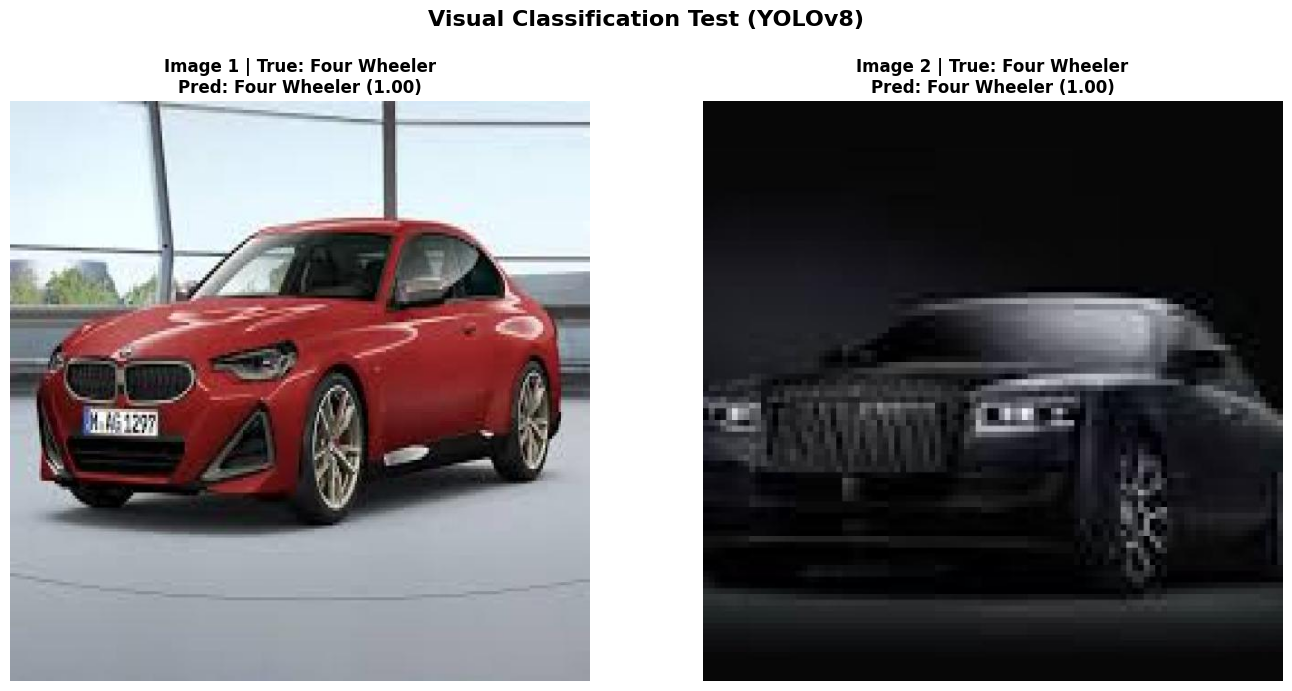

In [1]:
import os
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO


CLS_WEIGHTS_V8 = "runs/classify/yolov8n_cls_benchmark/weights/best.pt"

CLS_TEST_ROOT = "datasets" 

LABEL_MAP = {
    "Car": "Four Wheeler",
    "Bike": "Two Wheeler",
    "car": "Four Wheeler",
    "bike": "Two Wheeler"
}

def get_two_random_test_images(root_dir):
    """Gathers paths and labels for two arbitrary test images."""
    test_path = os.path.join(root_dir, "test")
    
    # Get all class directories
    class_dirs = [d for d in os.listdir(test_path) if os.path.isdir(os.path.join(test_path, d))]
    
    # Collect all image paths and their true labels
    all_images = []
    for d in class_dirs:
        class_path = os.path.join(test_path, d)
        img_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        for f in img_files:
            all_images.append({"path": os.path.join(class_path, f), "true_label": d})

    # Select two unique random images for comparison
    if len(all_images) >= 2:
        return random.sample(all_images, 2)
    return []

def classify_and_plot(model, image_data, ax, idx):
    """Classifies a single image and plots the result on the given axis."""
    
    image_path = image_data['path']
    true_label = image_data['true_label']
    
    # 1. Prediction
    results = model.predict(image_path, verbose=False)[0]
    
    pred_class_index = results.probs.top1
    pred_confidence = float(results.probs.top1conf)
    raw_pred_label = results.names[pred_class_index]
    
    # 2. Apply Mapping to User's Labels
    mapped_true_label = LABEL_MAP.get(true_label, true_label)
    mapped_pred_label = LABEL_MAP.get(raw_pred_label, raw_pred_label)

    # 3. Load Image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 4. Plotting
    ax.imshow(img)
    ax.set_title(f"Image {idx+1} | True: {mapped_true_label}\nPred: {mapped_pred_label} ({pred_confidence:.2f})", fontsize=12, fontweight='bold')
    ax.axis('off')

# --- MAIN EXECUTION ---
images_to_test = get_two_random_test_images(CLS_TEST_ROOT)

if not os.path.exists(CLS_WEIGHTS_V8):
    print(f"❌ YOLOv8 Model Not Found at {CLS_WEIGHTS_V8}. Cannot run visual test.")
elif len(images_to_test) == 2:
    print(f"🎯 Testing 2 images simultaneously with YOLOv8-Classification.")
    
    # Load model once
    model = YOLO(CLS_WEIGHTS_V8)
    
    fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    fig.suptitle(f"Visual Classification Test (YOLOv8)", fontsize=16, fontweight='bold')

    for i, img_data in enumerate(images_to_test):
        classify_and_plot(model, img_data, ax[i], i)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

else:
    print(f"❌ Could not find at least two images in the expected structure under '{CLS_TEST_ROOT}/test'.")